In [1]:
import pandas as pd

df = pd.read_csv('data/train.csv')
print(df.head)
print(df.shape)

<bound method NDFrame.head of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       pi

In [2]:
print(type(df.columns))

<class 'pandas.Index'>


In [3]:
input_features = df.columns.drop('label')
print(input_features)

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=784)


In [4]:
target = 'label'

In [5]:
X = df[input_features]
Y = df[target]
print(X.head())
print(Y.head())

   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

In [6]:
import torch
X_tensor = torch.tensor(X.values, dtype = torch.float32)
Y_tensor = torch.tensor(Y.values, dtype = torch.long)

print(X_tensor.shape)
print(Y_tensor.shape)

torch.Size([42000, 784])
torch.Size([42000])


In [7]:
from torch.utils.data import Dataset

class DigitDataset(Dataset):

    def __init__(Self, X, Y):
        Self.X = X
        Self.Y = Y

    def __len__(Self):
        return len(Self.X)

    def __getitem__(Self, idx):
        return Self.X[idx], Self.Y[idx]

In [8]:
from torch.utils.data import DataLoader

dataset = DigitDataset(X_tensor, Y_tensor)
dataLoader = DataLoader(dataset, batch_size = 32, shuffle = True)

for X_batch, Y_batch in dataLoader:
    print(X_batch.shape)
    print(Y_batch.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
torch.Size([32])
torch.Size([32, 784])
tor

In [9]:
import torch.nn as nn

class DigitModel(nn.Module):
    def __init__(Self):
        super().__init__()

        Self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 10),
        )

    def forward(Self, x):
        return Self.network(x)

In [10]:
model = DigitModel()
print(model)

DigitModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [11]:
loss = nn.CrossEntropyLoss()

In [12]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

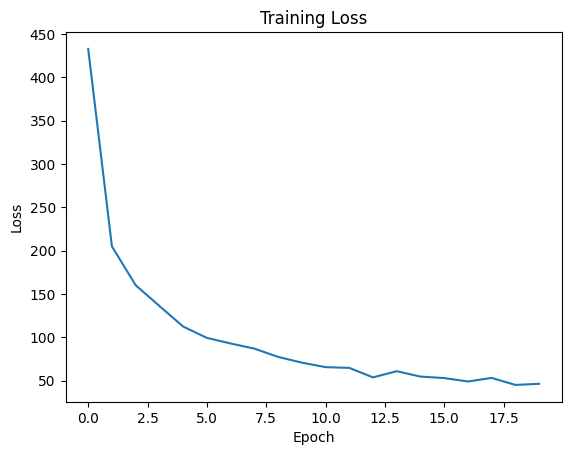

In [13]:
losses = []

for epoc in range(20):
    total_loss = 0
    for X_batch, Y_batch in dataLoader:
        outputs = model(X_batch)
        # Y_batch = Y_batch.unsqueeze(1)
        loss_batch = loss(outputs, Y_batch)
        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()
        total_loss = total_loss + loss_batch.item()
    losses.append(total_loss)

import matplotlib.pyplot as plt

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [14]:
model.eval()
with torch.no_grad():
    outputs = model(X_tensor)
    preds = outputs.argmax(dim = 1)
    correct = (preds == Y_tensor).sum().item()
    total = Y_tensor.shape[0]
    print((correct/total)*100)

99.33095238095238


In [17]:
df_test = pd.read_csv('data/test.csv')
print(df_test.head)
print(df_test.shape)

<bound method NDFrame.head of        pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
27995       0       0       0       0       0       0       0       0       0   
27996       0       0       0       0       0       0       0       0       0   
27997       0       0       0       0       0       0       0       0       0   
27998       0       0       0       0       0       0       0       0       0   
27999       0       0       0       0       0       0       0       0       0  

In [19]:
X_test = df_test[input_features]
print(X_test)

       pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
27995       0       0       0       0       0       0       0       0       0   
27996       0       0       0       0       0       0       0       0       0   
27997       0       0       0       0       0       0       0       0       0   
27998       0       0       0       0       0       0       0       0       0   
27999       0       0       0       0       0       0       0       0       0   

       pixel9  ...  pixel77

In [21]:
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32)
print(X_test_tensor.shape)

torch.Size([28000, 784])


In [22]:
outputs = model(X_test_tensor)
predictions_test = outputs.argmax(dim = 1)
image_ids = list(range(1, X_test.shape[0] + 1))
submission = pd.DataFrame({
    'ImageId': image_ids,
    'label': predictions_test
})
submission.to_csv("submission.csv", index = False)